DS Lab Session 5:
Graded Assignment
Kaggle Dataset link: https://www.kaggle.com/datasets/jkrithika/
chennai-2009-2024-weather-data

```
import pandas as pd
import os
import kagglehub
# Download the dataset using kagglehub
path = kagglehub.dataset_download(")
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Clean15YearChennaiWeather.)
# Read the CSV file into a pandas DataFrame
record_set_df = pd.read_csv(csv_file_path)
# Display the first few rows of the DataFrame
display(record_set_df.head())
```

1. Drop Date and Date ID from the Dataset
2. Compute the number of days with Fog, Partly cloudy, Broken clouds, Drizzle and plot the bar graph.
3. Compute the average temperature in each year and plot the results
as average temperature vs year.
4. Plot histogram for humidity
5. Plot freq polygon of humidity and temp like above for each year.
6. Compute Mode value desc.
7. Convert day name as 0: sunday 1: Monday and so on.
8. Plot average temperature on Sundays,
9. Plot a pie chart for barometer value <1001 on sundays.
10.Plot which date and month has more reading in each year.

In [132]:
import pandas as pd
import os
import kagglehub

# Download the dataset using kagglehub
path = kagglehub.dataset_download('jkrithika/chennai-2009-2024-weather-data')
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'Clean15YearChennaiWeather.csv')
# Read the CSV file into a pandas DataFrame
record_set_df = pd.read_csv(csv_file_path)
# Display the first few rows of the DataFrame
display(record_set_df.head())

Using Colab cache for faster access to the 'chennai-2009-2024-weather-data' dataset.


,date,date_id,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,"Sunday 14 July 2024, 18.00 — 00.00",1.720980e+12,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,"Monday 15 July 2024, 00.00 — 06.00",1.721002e+12,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,"Monday 15 July 2024, 06.00 — 12.00",1.721023e+12,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,"Monday 15 July 2024, 12.00 — 18.00",1.721045e+12,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,"Monday 15 July 2024, 18.00 — 00.00",1.721066e+12,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00


In [133]:
#1. Drop Date and Date ID from the Dataset
#removing duplicates
print("table count, before removing duplicate date_id rows",record_set_df.count())
record_set_df = record_set_df.drop_duplicates(subset=['date_id'], keep='first')
print("table count, after removing duplicate date_id rows",record_set_df.count())

record_set_df = record_set_df.drop(columns=['date', 'date_id'], axis=1)

# 'columns' specifies the columns to drop
# 'axis=1' specifies that we are dropping columns, not rows
print("\n\n Removed Date, Date ID");
display(record_set_df.head())




table count, before removing duplicate date_id rows date          1068
date_id       1068
wind          1068
desc          1068
temp          1038
baro          1068
hum           1068
day           1068
month         1068
day_date      1068
year          1068
day_name      1068
Start_hour    1068
End_hour      1068
dtype: int64
table count, after removing duplicate date_id rows date          641
date_id       641
wind          641
desc          641
temp          611
baro          641
hum           641
day           641
month         641
day_date      641
year          641
day_name      641
Start_hour    641
End_hour      641
dtype: int64


 Removed Date, Date ID


,wind,desc,temp,baro,hum,day,month,day_date,year,day_name,Start_hour,End_hour
0,9.0,Drizzle. Fog.,30.0,1003.0,82,2024-07-14,7,14,2024,6,18:00,00:00
1,14.0,Fog.,29.0,1002.0,80,2024-07-15,7,15,2024,0,00:00,06:00
2,17.0,Drizzle. Broken clouds.,29.0,1003.0,82,2024-07-15,7,15,2024,0,06:00,12:00
3,13.0,Drizzle. Broken clouds.,29.0,1001.0,85,2024-07-15,7,15,2024,0,12:00,18:00
4,19.0,Fog.,29.0,1002.0,84,2024-07-15,7,15,2024,0,18:00,00:00




Computed Frequencies
desc
Fog              65
Partly cloudy    56
Broken clouds    75
Drizzle          14


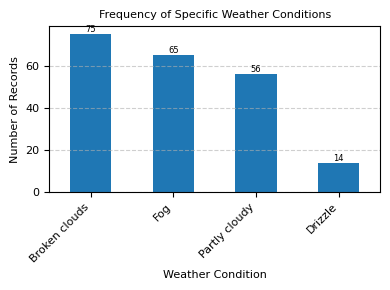

In [134]:
#Compute the number of days with Fog, Partly cloudy, Broken clouds, Drizzle and plot the bar graph.
import matplotlib.pyplot as plt

CONDITION_COLUMN = 'desc'
target_conditions = ['Fog', 'Partly cloudy', 'Broken clouds', 'Drizzle']

#some values has multiple conditions with "." separator, deviding such values.
all_conditions = record_set_df[CONDITION_COLUMN].str.split(r'\. ?') \
                                               .explode() \
                                               .str.strip()
all_conditions

#counting all the uniqueue values when it is not blank.
condition_counts = all_conditions[all_conditions != ''].value_counts()
condition_counts

#lets get the counts of problem statement ['Fog', 'Partly cloudy', 'Broken clouds', 'Drizzle']
filtered_counts = condition_counts.reindex(target_conditions, fill_value=0)
print("\n\nComputed Frequencies")
print(filtered_counts.to_string())

#plotting the values
sorted_counts = filtered_counts.sort_values(ascending=False)

plt.figure(figsize=(4, 3))
sorted_counts.plot(kind='bar', color='#1f77b4')

plt.title('Frequency of Specific Weather Conditions', fontsize=8)
plt.xlabel('Weather Condition', fontsize=8)
plt.ylabel('Number of Records', fontsize=8)

plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)

# Add the value of each bar on top
for index, value in enumerate(sorted_counts):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=6)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

--- Annual Average Temperature Data ---
   year       temp
0  2009  29.152582
1  2010  26.701613
2  2024  32.245902


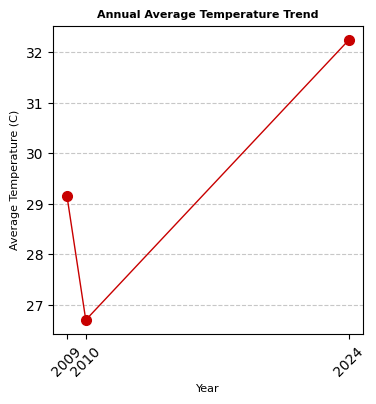

In [145]:
#3. Compute the average temperature in each year and plot the results as average temperature vs year.

#using group by, find average on temp for each year
annual_avg_temp = record_set_df.groupby('year')['temp'].mean().reset_index()

print("--- Annual Average Temperature Data ---")
print(annual_avg_temp.to_string())

plt.figure(figsize=(4, 4))

# Plot the data as a line plot (Avg Temp vs. Year)
plt.plot(annual_avg_temp['year'], annual_avg_temp['temp'],
         marker='o',             # Use circles for data points
         linestyle='-',          # Connect points with a line
         color='#C80000',        # Red line color
         linewidth=1,
         markersize=7)

plt.title('Annual Average Temperature Trend', fontsize=8, fontweight='bold')
plt.xlabel('Year', fontsize=8)
plt.ylabel('Average Temperature (C)', fontsize=8)

# Set x-ticks to show only the existing years
plt.xticks(annual_avg_temp['year'].unique(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

--- Descriptive Statistics for Humidity ---
count    641.000000
mean      74.330733
std       20.960524
min        0.000000
25%       67.000000
50%       79.000000
75%       88.000000
max      100.000000


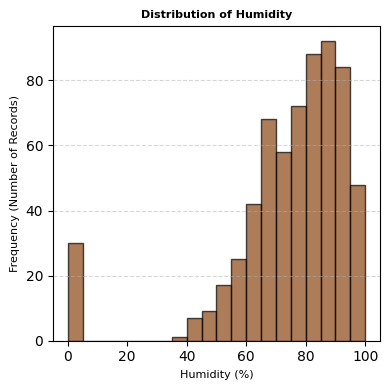

In [136]:
#4. Plot histogram for humidity
HUMIDITY_COLUMN = 'hum'

print("--- Descriptive Statistics for Humidity ---")
print(record_set_df[HUMIDITY_COLUMN].describe().to_string())

# Plotting the histogram
plt.figure(figsize=(4, 4))

# Plot the histogram
plt.hist(record_set_df[HUMIDITY_COLUMN],
          bins=20,                    # Use 20 bins for good detail
          color='#8B4513',            # Brown/Earth tone color
          edgecolor='black',
          alpha=0.7)

plt.title('Distribution of Humidity', fontsize=8, fontweight='bold')
plt.xlabel('Humidity (%)', fontsize=8)
plt.ylabel('Frequency (Number of Records)', fontsize=8)
plt.grid(axis='y', alpha=0.5, linestyle='--')
plt.tight_layout()

plt.show()


/tmp/ipython-input-1645742300.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('hsv', len(unique_years))


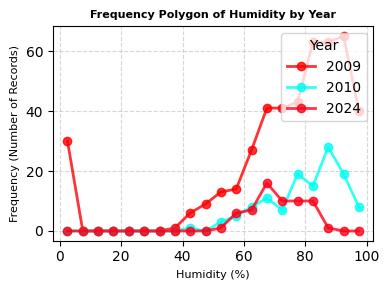

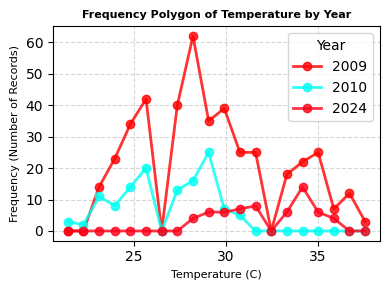

In [137]:
#5. Plot freq polygon of humidity and temp like above for each year.
import numpy as np

def plot_frequency_polygon(df, column_name, title, xlabel):
    """Generates and saves a frequency polygon plot for a column, grouped by year."""

    plt.figure(figsize=(4, 3))

    # Calculate global bins to ensure all years use the same scale for comparison
    min_val = df[column_name].min()
    max_val = df[column_name].max()
    bins = np.linspace(min_val, max_val, 21) # Creates 20 equal-width bins

    # Set up a colormap for distinct lines
    unique_years = df['year'].unique()
    colors = plt.cm.get_cmap('hsv', len(unique_years))

    for i, (year, group) in enumerate(df.groupby('year')):

        # 1. Calculate histogram data (counts and bin edges)
        counts, bin_edges = np.histogram(group[column_name], bins=bins)

        # 2. Calculate bin midpoints (x-axis values for the polygon)
        bin_midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2

        # 3. Plot the frequency polygon: counts vs midpoints
        plt.plot(bin_midpoints, counts,
                 marker='o', linestyle='-',
                 label=str(year),
                 color=colors(i),
                 alpha=0.8,
                 linewidth=2)

    plt.title(title, fontsize=8, fontweight='bold')
    plt.xlabel(xlabel, fontsize=8)
    plt.ylabel('Frequency (Number of Records)', fontsize=8)
    plt.legend(title='Year', loc='upper right')
    plt.grid(axis='both', linestyle='--', alpha=0.5)
    plt.tight_layout()

    plt.show() # Display the plot


# 1. Plot Frequency Polygon for Humidity
plot_frequency_polygon(
    record_set_df,
    column_name='hum',
    title='Frequency Polygon of Humidity by Year',
    xlabel='Humidity (%)'
)

# 2. Plot Frequency Polygon for Temperature
plot_frequency_polygon(
    record_set_df,
    column_name='temp',
    title='Frequency Polygon of Temperature by Year',
    xlabel='Temperature (C)'
)

In [138]:
#6. Compute Mode value desc.
DESC_COLUMN = 'desc'
mode_raw_desc = record_set_df[DESC_COLUMN].mode()


#mode of column as is
if not mode_raw_desc.empty:
    print("The most frequent full description string(s) are:")
    print(mode_raw_desc.to_string(header=False))
else:
    print("No unique mode found for the raw description string.")

print("\n\n")
# Mode of the individual conditions (e.g., 'Fog', 'Drizzle')
all_conditions = record_set_df[DESC_COLUMN].str.split(r'\. ?') \
                                           .explode() \
                                           .str.strip()
mode_individual_conditions = all_conditions[all_conditions != ''].mode()

if not mode_individual_conditions.empty:
    print("The most frequent individual weather condition(s) are:")
    print(mode_individual_conditions.to_string(header=False))
else:
    print("No unique mode found for individual conditions.")

The most frequent full description string(s) are:
0    Passing clouds.



The most frequent individual weather condition(s) are:
0    Passing clouds


In [146]:
#7. Convert day name as 0: sunday 1: Monday and so on.

DAY_NUMBER_COLUMN = 'day_name'
DAY_NAME_COLUMN = 'day_name_new'
day_code_mapping = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

# Assuming 'record_set_df' has a column called 'day_code'
record_set_df[DAY_NAME_COLUMN] = record_set_df[DAY_NUMBER_COLUMN].map(day_code_mapping)

# Display the original code and the restored name
print(record_set_df[[DAY_NUMBER_COLUMN, DAY_NAME_COLUMN]].head(10))

   day_name day_name_new
0         6     Saturday
1         0       Sunday
2         0       Sunday
3         0       Sunday
4         0       Sunday
5         1       Monday
6         1       Monday
7         1       Monday
8         1       Monday
9         2      Tuesday


Day column 0    Saturday
1      Sunday
2      Sunday
3      Sunday
4      Sunday
5      Monday
6      Monday
7      Monday
8      Monday
9     Tuesday
Name: day_name_new, dtype: object


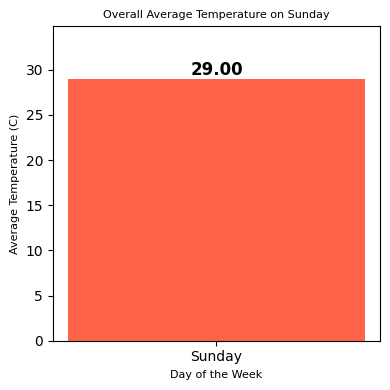

In [140]:
#8. Plot average temperature on Sundays,
TEMP_COLUMN = 'temp'
DAY_NAME_COLUMN = 'day_name_new'
TARGET_DAY = 'Sunday'

record_set_df[DAY_NAME_COLUMN] = record_set_df[DAY_NAME_COLUMN].astype(str).str.title()
print(f"Day column {record_set_df[DAY_NAME_COLUMN].head(10)}")
sunday_df = record_set_df[record_set_df[DAY_NAME_COLUMN] == TARGET_DAY].dropna(subset=[TEMP_COLUMN])

if sunday_df.empty:
    print(f"ERROR: No valid temperature data found for {TARGET_DAY} after cleaning.")
else:

  avg_temp_sunday = sunday_df[TEMP_COLUMN].mean()
  plt.figure(figsize=(4, 4))
  plt.bar(TARGET_DAY, avg_temp_sunday, color='#FF6347') # Tomato red color

  plt.text(TARGET_DAY, avg_temp_sunday, f'{avg_temp_sunday:.2f}',
          ha='center', va='bottom', fontsize=12, fontweight='bold')

  plt.title(f'Overall Average Temperature on {TARGET_DAY}', fontsize=8)
  plt.xlabel('Day of the Week', fontsize=8)
  plt.ylabel('Average Temperature (C)', fontsize=8)
  plt.ylim(0, avg_temp_sunday * 1.2) # Set y-limit for context
  plt.tight_layout()
  plt.show()

--- Barometer Counts on Sunday ---
Records with Barometer < 1001: 9
Records with Barometer >= 1001: 83


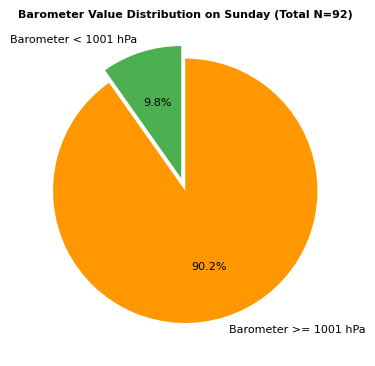

In [141]:
#9. Plot a pie chart for barometer value <1001 on sundays.
BARO_COLUMN = 'baro'
DAY_NAME_COLUMN = 'day_name_new'
TARGET_DAY = 'Sunday'
THRESHOLD = 1001

record_set_df[DAY_NAME_COLUMN] = record_set_df[DAY_NAME_COLUMN].astype(str).str.title()
sunday_df1 = record_set_df[record_set_df[DAY_NAME_COLUMN] == TARGET_DAY].dropna(subset=[BARO_COLUMN])

if sunday_df1.empty:
    print(f"Error: No valid data found for {TARGET_DAY} after cleaning. Cannot generate plot.")
else:
    is_low_baro = sunday_df1[BARO_COLUMN] < THRESHOLD

    low_baro_count = is_low_baro.sum()
    high_baro_count = (~is_low_baro).sum()

    counts = [low_baro_count, high_baro_count]
    labels = [f'Barometer < {THRESHOLD} hPa', f'Barometer >= {THRESHOLD} hPa']

    print(f"--- Barometer Counts on {TARGET_DAY} ---")
    print(f"Records with Barometer < {THRESHOLD}: {low_baro_count}")
    print(f"Records with Barometer >= {THRESHOLD}: {high_baro_count}")

    if sum(counts) > 0:
        # --- 3. Plot the Pie Chart ---
        plt.figure(figsize=(4, 4))

        # Highlight the lower count category using explode
        explode = [0.1, 0] if low_baro_count < high_baro_count else ([0, 0.1] if high_baro_count < low_baro_count else [0, 0])

        plt.pie(counts,
                labels=labels,
                autopct='%1.1f%%',
                startangle=90,
                colors=['#4CAF50', '#FF9800'],
                explode=explode,
                textprops={'fontsize': 8})

        plt.title(f'Barometer Value Distribution on {TARGET_DAY} (Total N={sum(counts)})', fontsize=8, fontweight='bold')
        plt.tight_layout()

        plt.show()
    else:
         print(f"Error: Total count of records is zero. Cannot generate pie chart.")

0       2024-07-14
1       2024-07-15
2       2024-07-15
3       2024-07-15
4       2024-07-15
           ...    
1063    2010-01-30
1064    2010-01-31
1065    2010-01-31
1066    2010-01-31
1067    2010-01-31
Name: day, Length: 641, dtype: object
0       7
1       7
2       7
3       7
4       7
       ..
1063    1
1064    1
1065    1
1066    1
1067    1
Name: month, Length: 641, dtype: int64
     year  Max Date Readings Mode Date
0    2009                  4    Sep 09
114  2010                  4    Jan 01
146  2024                  4    Jul 15
   year  Max Month Readings Mode Month
1  2009                 124        Oct
4  2010                 124        Jan
5  2024                  61        Jul


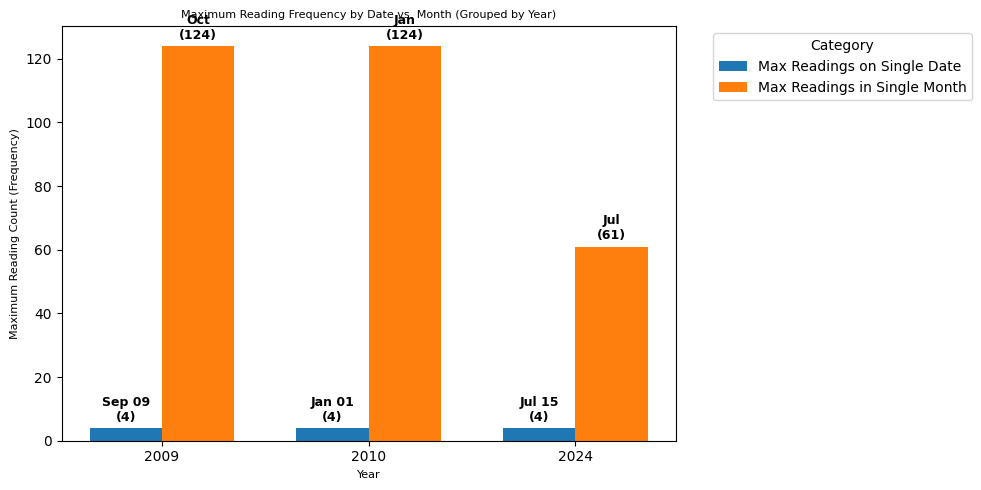

In [142]:
#10.Plot which date and month has more reading in each year.
import calendar

DATE_COLUMN = 'day'
DAY_COLUMN = 'day_date'
YEAR_COLUMN = 'year'
MONTH_COLUMN = 'month'


print(record_set_df[DATE_COLUMN])
print(record_set_df[MONTH_COLUMN])
record_set_df[DATE_COLUMN] = pd.to_datetime(record_set_df[DATE_COLUMN])

readings_by_date = record_set_df.groupby([YEAR_COLUMN, DATE_COLUMN]).size().reset_index(name='date_count')
max_date_freq = readings_by_date.loc[readings_by_date.groupby(YEAR_COLUMN)['date_count'].idxmax()]
max_date_freq['Mode Date'] = max_date_freq[DATE_COLUMN].dt.strftime('%b %d')
max_date_freq = max_date_freq.rename(columns={'date_count': 'Max Date Readings'})[['year', 'Max Date Readings', 'Mode Date']]
print(max_date_freq)

readings_by_month = record_set_df.groupby([YEAR_COLUMN, MONTH_COLUMN]).size().reset_index(name='month_count')
max_month_freq = readings_by_month.loc[readings_by_month.groupby(YEAR_COLUMN)['month_count'].idxmax()]
max_month_freq['Mode Month'] = max_month_freq[MONTH_COLUMN].apply(lambda x: calendar.month_abbr[x])
max_month_freq = max_month_freq.rename(columns={'month_count': 'Max Month Readings'})[['year', 'Max Month Readings', 'Mode Month']]
print(max_month_freq)

plot_df = pd.merge(max_date_freq, max_month_freq, on=YEAR_COLUMN, how='outer').fillna(0)
plot_df[YEAR_COLUMN] = plot_df[YEAR_COLUMN].astype(str)

plt.figure(figsize=(10, 5))
X = np.arange(len(plot_df))
width = 0.35
rects1 = plt.bar(X - width/2, plot_df['Max Date Readings'], width, label='Max Readings on Single Date', color='#1f77b4')
rects2 = plt.bar(X + width/2, plot_df['Max Month Readings'], width, label='Max Readings in Single Month', color='#ff7f0e')

# Loop to attach customized labels
for i, (r1, r2) in enumerate(zip(rects1, rects2)):
    # 1st Bar Label (Date and Count)
    date_val = plot_df['Mode Date'].iloc[i]
    count1 = int(r1.get_height())
    if count1 > 0:
        plt.annotate(f'{date_val}\n({count1})',
                    xy=(r1.get_x() + r1.get_width() / 2, count1),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

    # 2nd Bar Label (Month and Count)
    month_val = plot_df['Mode Month'].iloc[i]
    count2 = int(r2.get_height())
    if count2 > 0:
        plt.annotate(f'{month_val}\n({count2})',
                    xy=(r2.get_x() + r2.get_width() / 2, count2),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

plt.ylabel('Maximum Reading Count (Frequency)', fontsize=8)
plt.xlabel('Year', fontsize=8)
plt.title('Maximum Reading Frequency by Date vs. Month (Grouped by Year)', fontsize=8)
plt.xticks(X, plot_df[YEAR_COLUMN], rotation=0)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), title='Category')
plt.tight_layout()
plt.show()
